In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np

from functools import partial
from itertools import product
from typing import NamedTuple

Array = jax.Array

In [2]:
plt.style.use("seaborn-v0_8-colorblind")

## Time homogeneous vs time inhomogeneous Markov Chains

In [3]:
class StepState(NamedTuple):
    curr_rng: jrandom.PRNGKey
    done_t: Array
    curr_s: Array
    curr_transition: Array

@partial(jax.vmap, in_axes=[0, 0, None])
def sample_transition(rng, curr_s, transition):
    return jrandom.choice(
        rng,
        len(transition[curr_s]),
        p=transition[curr_s],
    )

def simulate(rng, transition, init_dist, num_samples, T, K, transition_dynamics, done_state):
    B = T * K

    @jax.jit
    def step(step_i, step_state):
        curr_s = step_state.curr_s
        curr_transition = step_state.curr_transition
        curr_transition = transition_dynamics(
            step_i,
            curr_transition,
            T,
            K,
        )

        done_t = step_state.done_t
        done_t = jax.lax.select(
            jnp.logical_and(
                curr_s == done_state,
                jnp.logical_not(jnp.isfinite(done_t)),
            ),
            jnp.full_like(done_t, fill_value=step_i),
            done_t,
        )

        curr_rng = jrandom.fold_in(
            step_state.curr_rng,
            step_i,
        )
        curr_rng = jrandom.split(curr_rng, num_samples)

        next_s = sample_transition(
            curr_rng,
            curr_s,
            curr_transition,
        )

        return StepState(
            curr_rng=rng,
            done_t=done_t,
            curr_s=next_s,
            curr_transition=curr_transition,
        )

    init_state = jrandom.choice(
        rng,
        len(init_dist),
        p=init_dist,
        shape=(num_samples,),
    )

    return jax.lax.fori_loop(
        0,
        B,
        step,
        StepState(
            curr_rng=rng,
            done_t=np.full(num_samples, fill_value=jnp.nan),
            curr_s=init_state,
            curr_transition=transition,
        )
    )

def two_state_mean_ht(T, p):
    return (1 - (T + 1) * (p ** T) + T * (p ** (T + 1))) / ((1 - p) * (1 - p ** T))

### Plotting utils

In [4]:
def plot_success_rate(all_res, discountings, p_range):
    num_cols = 3
    num_rows = int(np.ceil(len(discountings) / num_cols))
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        layout="constrained",
        figsize=(2.5 * num_cols, 2.5 * num_rows),
    )

    axes = axes.flatten()
    for discount_i, discounting in enumerate(discountings):
        ax = axes[discount_i]

        discount_res = all_res[discounting]
        for tk_pair, curr_res in discount_res.items():
            hit_success = np.array([
                np.mean(jnp.isfinite(curr_res[curr_p].done_t))
                for curr_p in p_range
            ])
            ax.plot(
                p_range,
                hit_success,
                label=f"T: {tk_pair[0]}, K: {tk_pair[1]}" if discount_i == 0 else ""
            )

        ax.set_title(f"{discounting}")
        ax.set_ylim(-0.1, 1.1)

    for i in range(len(discountings), len(axes)):
        fig.delaxes(axes[i])

    fig.supxlabel("$P(X_{{t+1}} = S | X_t = S)$")
    fig.supylabel("Hit success")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=7,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

In [5]:
def plot_expected_hitting_time(all_res, discountings, p_range, T, K, n_states):
    num_cols = 3
    num_rows = int(np.ceil(len(discountings) / num_cols))
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        layout="constrained",
        figsize=(2.5 * num_cols, 2.5 * num_rows),
    )

    colours = [
        "blue",
        "red",
        "yellow",
        "gray",
    ]

    axes = axes.flatten()
    for discount_i, discounting in enumerate(discountings):
        ax = axes[discount_i]

        discount_res = all_res[discounting]
        for tk_pair, curr_res in discount_res.items():
            mean_hitting_time = np.array([
                jnp.nanmean(curr_res[curr_p].done_t)
                for curr_p in p_range
            ])
            std_hitting_time = np.array([
                jnp.nanstd(curr_res[curr_p].done_t)
                for curr_p in p_range
            ]) / jnp.sqrt(
                np.array([
                    np.sum(jnp.isfinite(curr_res[curr_p].done_t))
                    for curr_p in p_range
                ])
            )

            ax.plot(
                p_range,
                mean_hitting_time,
                label=f"K: {tk_pair[0]}, T: {tk_pair[0] * tk_pair[1]}" if discount_i == 0 else "",
            )
            ax.fill_between(
                p_range,
                mean_hitting_time - std_hitting_time,
                mean_hitting_time + std_hitting_time,
                alpha=0.2,
            )

        if n_states == 2:
            ax.plot(
                p_range,
                [two_state_mean_ht(tk_pair[0] * tk_pair[1], curr_p) for curr_p in p_range],
                linestyle="dashed",
                alpha=0.3,
                color="black",
                label=f"Theoretical mean HT" if discount_i == 0 else "",
            )
        ax.set_title(f"{discounting}")
        ax.set_ylim(0.0, T * K)

    for i in range(len(discountings), len(axes)):
        fig.delaxes(axes[i])

    fig.supxlabel("$P(X_{{t+1}} = S | X_t = S)$")
    fig.supylabel("Expected hitting time")
    fig.suptitle("Decay rate")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=7,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

In [6]:
def plot_expected_hitting_time_by_T(all_res, p_range, Ts):
    num_cols = 3
    num_rows = int(np.ceil(len(p_range) / num_cols))
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        layout="constrained",
        figsize=(2.5 * num_cols, 2.5 * num_rows),
    )
    axes = axes.flatten()

    for p_i, curr_p in enumerate(p_range):
        for k, res in all_res[curr_p].items():
            mean_hitting_time = np.array([
                jnp.nanmean(res[T].done_t)
                for T in Ts
            ])
            std_hitting_time = np.array([
                jnp.nanstd(res[T].done_t)
                for T in Ts
            ]) / jnp.sqrt(
                np.array([
                    np.sum(jnp.isfinite(res[T].done_t))
                    for T in Ts
                ])
            )
            axes[p_i].errorbar(
                Ts,
                mean_hitting_time,
                yerr=std_hitting_time,
                label=k if p_i == 0 else "",
            )
        axes[p_i].set_title(f"$P(X_t \\to S)={curr_p:.2f}$")
        # axes[p_i].set_ylim(0.0, np.max(Ts))

    for i in range(len(p_range), len(axes)):
        fig.delaxes(axes[i])

    fig.supxlabel("$T$")
    fig.supylabel("Expected hitting time")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=5,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

In [7]:
def plot_success_rate_by_T(all_res, p_range, Ts):
    num_cols = 3
    num_rows = int(np.ceil(len(p_range) / num_cols))
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        layout="constrained",
        figsize=(2.5 * num_cols, 2.5 * num_rows),
    )
    axes = axes.flatten()

    for p_i, curr_p in enumerate(p_range):
        for k, res in all_res[curr_p].items():
            hit_success = np.array([
                np.mean(jnp.isfinite(res[T].done_t))
                for T in Ts
            ])
            axes[p_i].plot(
                Ts,
                hit_success,
                label=k if p_i == 0 else "",
            )
        axes[p_i].set_title(f"P(X_t -> s)={curr_p:.2f}")
        axes[p_i].set_ylim(-0.1, 1.1)

    for i in range(len(p_range), len(axes)):
        fig.delaxes(axes[i])

    fig.supxlabel("$T$")
    fig.supylabel("P(success by timestep $T$)")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=5,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

In [8]:
seed = 42
num_samples = 1000

rng = jrandom.PRNGKey(seed)

## 2-state MC

In [ ]:
all_res = {}

tk_pairs = (
    (1, 10),
    (2, 5),
    (5, 2),
    (10, 1),
)

discountings = (0.4, 0.5, 0.6, 0.7, 0.8, 0.9)

p_range = np.arange(0.0, 1.0, 0.05)
init_dist = np.array([1.0, 0.0])

for discount_i, discounting in enumerate(discountings):
    all_res.setdefault(discounting, dict())

    def transition_dynamics(step_i, curr_transition, T, K):
        curr_p = jax.lax.select(
            (step_i + 1) % T == 0,
            curr_transition[0, 0] * discounting,
            curr_transition[0, 0],
        )
        curr_transition = jnp.array([
            [curr_p, 1 - curr_p],
            [0.0, 1.0],
        ])
        return curr_transition

    for (T, K) in tk_pairs:
        all_res[discounting].setdefault((T, K), dict())
        for curr_p in p_range:
            curr_transition = np.array([
                [curr_p, 1.0 - curr_p],
                [0.0, 1.0],
            ])
            all_res[discounting][(T, K)][curr_p] = simulate(
                rng,
                curr_transition,
                init_dist,
                num_samples,
                T,
                K,
                transition_dynamics,
                done_state=1,
            )

In [ ]:
plot_success_rate(all_res, discountings, p_range)

In [ ]:
plot_expected_hitting_time(all_res, discountings, p_range, T, K, n_states=2)

## 3-state MC

In [ ]:
all_res = {}

p_range = [0.0, 0.2, 0.4, 0.6, 0.8]

for curr_p in p_range:
    all_res.setdefault(curr_p, dict())
    transitions = {
        "deterministic s->a": np.array([
            [0.0, 1.0, 0.0],
            [curr_p, 0.0, 1 - curr_p],
            [0.0, 0.0, 1.0],
        ]),
        "deterministic a->g": np.array([
            [curr_p, 1 - curr_p, 0.0],
            [0.0, 0.0, 1.0],
            [0.0, 0.0, 1.0],
        ]),
        "0.5 s->a": np.array([
            [0.5, 0.5, 0.0],
            [curr_p, 0.0, 1 - curr_p],
            [0.0, 0.0, 1.0],
        ]),
        "0.5 a->g": np.array([
            [curr_p, 1 - curr_p, 0.0],
            [0.5, 0.0, 0.5],
            [0.0, 0.0, 1.0],
        ]),
    }
    init_dist = np.array([1.0, 0.0, 0.0])

    def transition_dynamics(step_i, curr_transition, T, K):
        return curr_transition

    Ts = np.arange(1, 51, 5)

    for k, curr_transition in transitions.items():
        all_res[curr_p].setdefault(k, dict())
        for T in Ts:
            all_res[curr_p][k][T] = simulate(
                rng,
                curr_transition,
                init_dist,
                num_samples,
                T,
                1,
                transition_dynamics,
                done_state=2,
            )

In [ ]:
plot_expected_hitting_time_by_T(
    all_res,
    p_range,
    Ts,
)

In [ ]:
plot_success_rate_by_T(
    all_res,
    p_range,
    Ts,
)

## 4-state MC

In [ ]:
all_res = {}

p_range = [0.0, 0.2, 0.4, 0.6, 0.8]

for curr_p in p_range:
    all_res.setdefault(curr_p, dict())
    transitions = {
        "random s->a": np.array([
            [curr_p, 1 - curr_p, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 1.0],
        ]),
        "random a->b": np.array([
            [0.0, 1.0, 0.0, 0.0],
            [curr_p, 0.0, 1 - curr_p, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 1.0],
        ]),
        "random b->g": np.array([
            [0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0],
            [curr_p, 0.0, 0.0, 1 - curr_p],
            [0.0, 0.0, 0.0, 1.0],
        ]),
    }
    init_dist = np.array([1.0, 0.0, 0.0, 0.0])

    def transition_dynamics(step_i, curr_transition, T, K):
        return curr_transition

    Ts = np.arange(1, 51, 5)

    for k, curr_transition in transitions.items():
        all_res[curr_p].setdefault(k, dict())
        for T in Ts:
            all_res[curr_p][k][T] = simulate(
                rng,
                curr_transition,
                init_dist,
                num_samples,
                T,
                1,
                transition_dynamics,
                done_state=3,
            )

In [ ]:
plot_expected_hitting_time_by_T(
    all_res,
    p_range,
    Ts,
)

In [ ]:
plot_success_rate_by_T(
    all_res,
    p_range,
    Ts,
)

## 5-state MC

In [ ]:
all_res = {}

p_range = [0.0, 0.2, 0.4, 0.6, 0.8]

for curr_p in p_range:
    all_res.setdefault(curr_p, dict())
    transitions = {
        "random $S \\to N_1$": np.array([
            [curr_p, 1 - curr_p, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
        "random $N_1 \\to N_2$": np.array([
            [0.0, 1.0, 0.0, 0.0, 0.0],
            [curr_p, 0.0, 1 - curr_p, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
        "random $N_2 \\to N_3$": np.array([
            [0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0],
            [curr_p, 0.0, 0.0, 1 - curr_p, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
        "random $N_3 \\to G$": np.array([
            [0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0, 0.0],
            [curr_p, 0.0, 0.0, 0.0, 1 - curr_p],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
    }
    init_dist = np.array([1.0, 0.0, 0.0, 0.0, 0.0])

    def transition_dynamics(step_i, curr_transition, T, K):
        return curr_transition

    Ts = np.arange(1, 51, 5)

    for k, curr_transition in transitions.items():
        all_res[curr_p].setdefault(k, dict())
        for T in Ts:
            all_res[curr_p][k][T] = simulate(
                rng,
                curr_transition,
                init_dist,
                num_samples,
                T,
                1,
                transition_dynamics,
                done_state=4,
            )

In [ ]:
plot_expected_hitting_time_by_T(
    all_res,
    p_range,
    Ts,
)

In [ ]:
plot_success_rate_by_T(
    all_res,
    p_range,
    Ts,
)

### 5-state MC with self-loop instead of hard resets

In [ ]:
all_res = {}

p_range = [0.0, 0.2, 0.4, 0.6, 0.8]

for curr_p in p_range:
    all_res.setdefault(curr_p, dict())
    transitions = {
        "random $S \\to N_1$": np.array([
            [curr_p, 1 - curr_p, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
        "random $N_1 \\to N_2$": np.array([
            [0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, curr_p, 1 - curr_p, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
        "random $N_2 \\to N_3$": np.array([
            [0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, curr_p, 1 - curr_p, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
        "random $N_3 \\to G$": np.array([
            [0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, curr_p, 1 - curr_p],
            [0.0, 0.0, 0.0, 0.0, 1.0],
        ]),
    }
    init_dist = np.array([1.0, 0.0, 0.0, 0.0, 0.0])

    def transition_dynamics(step_i, curr_transition, T, K):
        return curr_transition

    Ts = np.arange(1, 51, 5)

    for k, curr_transition in transitions.items():
        all_res[curr_p].setdefault(k, dict())
        for T in Ts:
            all_res[curr_p][k][T] = simulate(
                rng,
                curr_transition,
                init_dist,
                num_samples,
                T,
                1,
                transition_dynamics,
                done_state=4,
            )

In [ ]:
plot_expected_hitting_time_by_T(
    all_res,
    p_range,
    Ts,
)

In [ ]:
plot_success_rate_by_T(
    all_res,
    p_range,
    Ts,
)

TODO:
- Check dynamics of varying two stochastic transitions
  - In varying only one stochastic transitions, it seems like focusing on the later transitions improve hitting time---this makes sense because failing on later steps requires extra more time to reach the same state again

## 5-state MC with two stochastic transitions

In [ ]:
all_res = {}

p_range = [0.0, 0.2, 0.4, 0.6, 0.8]

num_states = 6

det_transitions = np.eye(num_states)
init_dist = np.copy(det_transitions[0])
det_transitions[:-1] = np.roll(det_transitions[:-1], 1, axis=1)

def transition_dynamics(step_i, curr_transition, T, K):
    return curr_transition

for curr_p in p_range:
    all_res.setdefault(curr_p, dict())
    
    transitions = dict()
    for s_i, s_j in product(range(num_states - 1), repeat=2):
        if s_i >= s_j:
            continue

        transitions[f"random {s_i} and {s_j}"] = np.copy(det_transitions)
        transitions[f"random {s_i} and {s_j}"][s_i, s_i + 1] = 1 - curr_p
        transitions[f"random {s_i} and {s_j}"][s_i, 0] = curr_p
        transitions[f"random {s_i} and {s_j}"][s_j, s_j + 1] = 1 - curr_p
        transitions[f"random {s_i} and {s_j}"][s_j, 0] = curr_p
        assert np.sum(transitions[f"random {s_i} and {s_j}"][s_i]) == 1.0
        assert np.sum(transitions[f"random {s_i} and {s_j}"][s_j]) == 1.0

    Ts = np.arange(1, 101, 10)

    for k, curr_transition in transitions.items():
        all_res[curr_p].setdefault(k, dict())
        for T in Ts:
            all_res[curr_p][k][T] = simulate(
                rng,
                curr_transition,
                init_dist,
                num_samples,
                T,
                1,
                transition_dynamics,
                done_state=num_states - 1,
            )

In [ ]:
plot_expected_hitting_time_by_T(
    all_res,
    p_range,
    Ts,
)

In [ ]:
plot_success_rate_by_T(
    all_res,
    p_range,
    Ts,
)

## 5-state MC with random transitions

In [49]:
def plot_expected_hitting_time_by_T(all_res, Ts):
    num_cols = 1
    num_rows = 1
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        layout="constrained",
        figsize=(5.0 * num_cols, 5.0 * num_rows),
    )

    for k, res in all_res.items():
        mean_hitting_time = np.array([
            jnp.nanmean(res[T].done_t)
            for T in Ts
        ])
        std_hitting_time = np.array([
            jnp.nanstd(res[T].done_t)
            for T in Ts
        ]) / jnp.sqrt(
            np.array([
                np.sum(jnp.isfinite(res[T].done_t))
                for T in Ts
            ])
        )
        axes.errorbar(
            Ts,
            mean_hitting_time,
            yerr=std_hitting_time,
            label=k,
        )
    axes.set_title("Varying failure probabilities")

    fig.supxlabel("$T$")
    fig.supylabel("Expected hitting time")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=3,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

In [48]:
all_res = {}

p_range = [0.0, 0.2, 0.4, 0.6, 0.8]

num_states = 5

init_dist = np.eye(num_states)[0]

def transition_dynamics(step_i, curr_transition, T, K):
    return curr_transition

failure_probs = [
    (0.5, 0.5, 0.0, 0.0),
    (0.0, 0.0, 0.5, 0.5),
    (0.5, 0.0, 0.0, 0.5),
    (0.0, 0.5, 0.5, 0.0),
    (0.5, 0.0, 0.5, 0.0),
    (0.0, 0.5, 0.0, 0.5),
]

for curr_failure_probs in failure_probs:
    all_res.setdefault(curr_failure_probs, dict())
    
    transitions = dict()
    
    det_transitions = np.zeros((num_states, num_states))
    for row_i, curr_p in enumerate(
        curr_failure_probs
    ):
        det_transitions[row_i, 0] = curr_p
        det_transitions[row_i, row_i + 1] = 1 - curr_p
    det_transitions[-1, -1] = 1.0
    print(det_transitions)
    assert np.all(np.sum(det_transitions, axis=1) == 1.0)

    Ts = np.arange(1, 101, 10)

    for T in Ts:
        all_res[curr_failure_probs][T] = simulate(
            rng,
            det_transitions,
            init_dist,
            num_samples,
            T,
            1,
            transition_dynamics,
            done_state=num_states - 1,
        )

[[0.5 0.5 0.  0.  0. ]
 [0.5 0.  0.5 0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1. ]
 [0.  0.  0.  0.  1. ]]
[[0.  1.  0.  0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.5 0.  0.  0.5 0. ]
 [0.5 0.  0.  0.  0.5]
 [0.  0.  0.  0.  1. ]]
[[0.5 0.5 0.  0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.5 0.  0.  0.  0.5]
 [0.  0.  0.  0.  1. ]]
[[0.  1.  0.  0.  0. ]
 [0.5 0.  0.5 0.  0. ]
 [0.5 0.  0.  0.5 0. ]
 [0.  0.  0.  0.  1. ]
 [0.  0.  0.  0.  1. ]]
[[0.5 0.5 0.  0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.5 0.  0.  0.5 0. ]
 [0.  0.  0.  0.  1. ]
 [0.  0.  0.  0.  1. ]]
[[0.  1.  0.  0.  0. ]
 [0.5 0.  0.5 0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.5 0.  0.  0.  0.5]
 [0.  0.  0.  0.  1. ]]


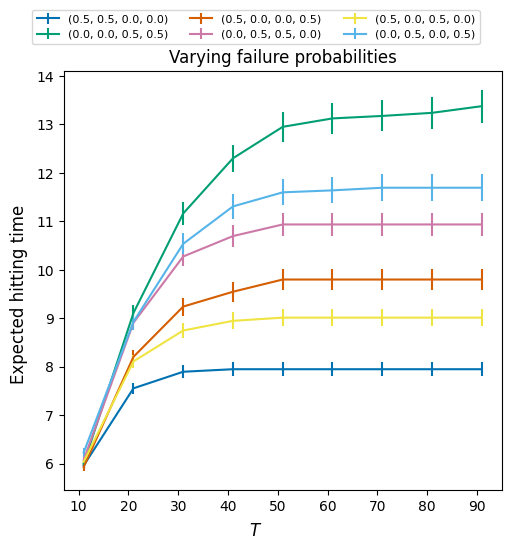

In [50]:
plot_expected_hitting_time_by_T(
    all_res,
    Ts,
)

In [ ]:
assert 0